# 🐧 Práctica 01 — Análisis Exploratorio de Datos
### Cátedra Aprendizaje Automático

---

**Objetivo:** recorrer el flujo completo de EDA sobre un dataset real:
carga → exploración → limpieza → análisis → visualización.

**Dataset:** *Palmer Penguins* — mediciones de tres especies de pingüinos
registradas en las Islas Palmer, Antártida (2007–2009).

| Variable | Descripción |
|----------|-------------|
| `species` | Especie: Adelie, Chinstrap, Gentoo |
| `island` | Isla donde fue observado |
| `bill_length_mm` | Largo del pico (mm) |
| `bill_depth_mm` | Profundidad del pico (mm) |
| `flipper_length_mm` | Largo de la aleta (mm) |
| `body_mass_g` | Masa corporal (gramos) |
| `sex` | Sexo |

---

**Instrucciones:**
- Completá cada celda de código donde veas `# TU CÓDIGO AQUÍ` o `___`.
- Ejecutá las celdas en orden con `Shift + Enter`.
- Si te trabás, revisá el **💡 Hint** de la sección.
- Al final hay celdas de verificación automática para algunas respuestas.

---

## Parte 0 — Setup

Primero importamos las librerías. Esta celda ya está completa — solo ejecutala.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## Parte 1 — Cargar el Dataset

Seaborn incluye el dataset Penguins. Cargalo y guardalo en una variable llamada `df`.

> 💡 **Hint:** `sns.load_dataset("nombre_del_dataset")`

In [7]:
# Cargá el dataset "penguins" de seaborn
df = sns.load_dataset('penguins')
df

# Mostrá las primeras 5 filas
df.head(5)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [8]:
# ── Verificación automática ──────────────────────────────
assert 'df' in dir(), "❌ La variable df no existe — ¿la creaste?"
assert isinstance(df, pd.DataFrame), "❌ df debe ser un DataFrame"
assert df.shape == (344, 7), f"❌ El dataset debe tener 344 filas y 7 columnas, tiene {df.shape}"
print("✅ ¡Correcto! Dataset cargado:", df.shape)

✅ ¡Correcto! Dataset cargado: (344, 7)


---
## Parte 2 — Exploración Inicial

Antes de limpiar o modelar, necesitamos entender **qué tenemos**.

### 2.1 Estructura del dataset

Completá las celdas para responder cada pregunta.

In [11]:
# ¿Cuántas filas y columnas tiene el dataset?
filas, columnas = df.shape
print(f"Filas: {filas} | Columnas: {columnas}")

Filas: 344 | Columnas: 7


In [12]:
# ¿Cuáles son los tipos de datos de cada columna?
print(df.dtypes)

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


In [15]:
# Mostrá un resumen estadístico de las columnas NUMÉRICAS 
df.describe() # El describe solo me devuelve el estadistico de columnas numericas
# No hace falta pasarle parametros para verlo
# df.info() # Esto te da informacion del dataframe como por ejemplo: el tipo de datos, las columnas y sus tipos de datos, la memoria etc

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### 2.2 Variables categóricas

Para las columnas no numéricas necesitamos `value_counts()`.

In [19]:
# ¿Cuántos pingüinos hay de cada especie?
print("--- Especies ---")
print(df['species'].value_counts()) # El value counts nos devuelve un valor unico para cada columna
# Esto funciona como cualquier lenguaje para obtener una posicion o columna del array
# Especificamos el array (df) y la columna []

# ¿Y en cuántas islas?
print("\n--- Islas ---")
print(df['island'].value_counts())

--- Especies ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

--- Islas ---
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


### 2.3 Valores faltantes

Los valores `NaN` (Not a Number) son uno de los mayores problemas en datos reales.

> 💡 **Hint:** `df.isnull()` devuelve True/False para cada celda.  
> `.sum()` sobre eso cuenta los True por columna.

In [29]:
# Contá los valores faltantes por columna
nulos = df.isnull().sum()
print("Valores faltantes por columna:")
print(nulos)

# cantidad_nulos = nulos.sum()
# print(cantidad_nulos)

# Calculá también el porcentaje
print("\nPorcentaje faltante:")
print((nulos/ len(df) * 100).round(1).astype(str) + "%")



Valores faltantes por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Porcentaje faltante:
species              0.0%
island               0.0%
bill_length_mm       0.6%
bill_depth_mm        0.6%
flipper_length_mm    0.6%
body_mass_g          0.6%
sex                  3.2%
dtype: str
344


In [30]:
# ── Verificación ─────────────────────────────────────────
assert 'nulos' in dir(), "❌ La variable 'nulos' no existe"
assert nulos.sum() == 19, f"❌ Debe haber 19 nulos en total, encontraste {nulos.sum()}"
print(f"✅ Correcto: hay {nulos.sum()} valores faltantes en total")

✅ Correcto: hay 19 valores faltantes en total


---
## Parte 3 — Limpieza

Ahora que sabemos qué tenemos, vamos a limpiar.

### 3.1 Estrategia de imputación

Hay varias estrategias para manejar NaN:

| Estrategia | Método | Cuándo usarla |
|------------|--------|---------------|
| Eliminar filas | `dropna()` | Pocos nulos, no sesga |
| Imputar con media | `fillna(media)` | Variable numérica, distribución simétrica |
| Imputar con mediana | `fillna(mediana)` | Variable numérica con outliers |
| Imputar con moda | `fillna(moda)` | Variable categórica |

> 💡 **Hint para este dataset:** hay solo 11 filas con algún NaN (de 344).  
> Eliminarlas con `dropna()` es razonable aquí.

In [31]:
# Guardá el dataset original (buena práctica: no sobreescribir)
df_original = df.copy()

# Eliminá todas las filas con al menos un NaN
df_limpio = df.dropna()

print(f"Filas originales: {len(df_original)}")
print(f"Filas después de limpiar: {len(df_limpio)}")
print(f"Filas eliminadas: {len(df_original) - len(df_limpio)}")

Filas originales: 344
Filas después de limpiar: 333
Filas eliminadas: 11


In [32]:
# ── Verificación ─────────────────────────────────────────
assert 'df_limpio' in dir(), "❌ La variable df_limpio no existe"
assert df_limpio.isnull().sum().sum() == 0, "❌ Todavía hay valores nulos en df_limpio"
assert len(df_limpio) == 333, f"❌ df_limpio debe tener 333 filas, tiene {len(df_limpio)}"
print(f"✅ Dataset limpio: {df_limpio.shape[0]} filas, sin valores nulos")

✅ Dataset limpio: 333 filas, sin valores nulos


### 3.2 Crear nuevas variables (Feature Engineering)

A veces conviene crear nuevas columnas a partir de las existentes.

> 💡 **Hint:** podés operar columnas de un DataFrame como si fueran vectores.  
> `df["nueva"] = df["col_a"] / df["col_b"]`

In [34]:
# Creá una nueva columna "razon_pico" = bill_length_mm / bill_depth_mm
# (razón entre largo y profundidad del pico — potencialmente útil para clasificar especies)
df_limpio = df_limpio.copy()  # evitar SettingWithCopyWarning
df_limpio["razon_pico"] = df['bill_length_mm'] / df['bill_depth_mm']

print("Primeras filas con la nueva columna:")
df_limpio[["species", "bill_length_mm", "bill_depth_mm", "razon_pico"]].head(6)

Primeras filas con la nueva columna:


,species,bill_length_mm,bill_depth_mm,razon_pico
0,Adelie,39.1,18.7,2.090909
1,Adelie,39.5,17.4,2.270115
2,Adelie,40.3,18.0,2.238889
4,Adelie,36.7,19.3,1.901554
5,Adelie,39.3,20.6,1.907767
6,Adelie,38.9,17.8,2.185393


In [35]:
# Bonus: creá una columna "grande" que sea True si body_mass_g > 4500
df_limpio["grande"] = df['body_mass_g'] > 4500

print("¿Cuántos pingüinos 'grandes' hay?")
print(df_limpio["grande"].value_counts())

¿Cuántos pingüinos 'grandes' hay?
grande
False    221
True     112
Name: count, dtype: int64


---
## Parte 4 — Análisis con GroupBy

`groupby()` es una de las operaciones más poderosas de Pandas.  
Permite calcular estadísticas por grupo.

> 💡 **Sintaxis:** `df.groupby("columna_grupo")["columna_valor"].funcion()`

In [37]:
# Calculá el peso promedio (body_mass_g) de cada especie
peso_por_especie = df_limpio.groupby('species')['body_mass_g'].mean()
print("Peso promedio por especie (gramos):")
print(peso_por_especie.round(0))

Peso promedio por especie (gramos):
species
Adelie       3706.0
Chinstrap    3733.0
Gentoo       5092.0
Name: body_mass_g, dtype: float64


In [39]:
# Calculá la mediana del largo de aleta (flipper_length_mm) por especie Y por sexo
# Hint: podés pasar una lista a groupby()
aleta_por_especie_sexo = df_limpio.groupby(['species','sex'])["flipper_length_mm"].median()
print("Mediana del largo de aleta (mm):")
print(aleta_por_especie_sexo)

Mediana del largo de aleta (mm):
species    sex   
Adelie     Female    188.0
           Male      193.0
Chinstrap  Female    192.0
           Male      200.5
Gentoo     Female    212.0
           Male      221.0
Name: flipper_length_mm, dtype: float64


In [40]:
# Calculá múltiples estadísticas a la vez con .agg()
resumen = df_limpio.groupby("species")["body_mass_g"].agg(["mean", "std", "min", "max"])
resumen.columns = ["Media", "Desv. Est.", "Mínimo", "Máximo"]
resumen.round(1)

,Media,Desv. Est.,Mínimo,Máximo
species,,,,
Adelie,3706.2,458.6,2850.0,4775.0
Chinstrap,3733.1,384.3,2700.0,4800.0
Gentoo,5092.4,501.5,3950.0,6300.0


---
## Parte 5 — Visualización

Ahora vamos a graficar lo que aprendimos. Completá los gráficos.

### 5.1 Histograma — distribución de una variable

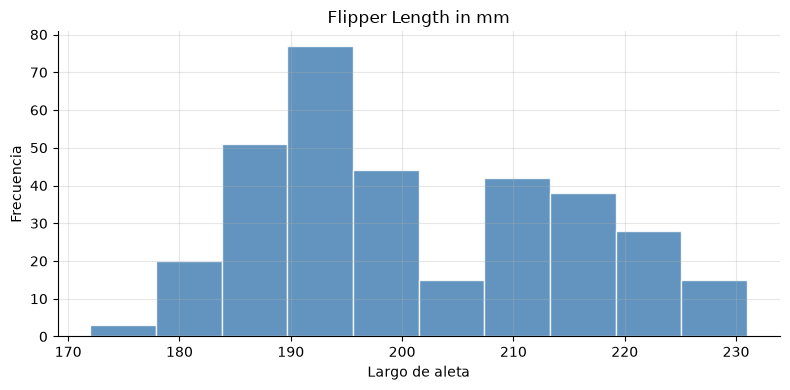

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

# Graficá un histograma de flipper_length_mm
# Hint: ax.hist(datos, bins=N, color="color", edgecolor="white")
ax.hist(df_limpio['flipper_length_mm'], bins='auto', color="steelblue", edgecolor="white", alpha=0.85)

# Agregá título y etiquetas a los ejes
ax.set_title('Flipper Length in mm')
ax.set_xlabel('Largo de aleta')
ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### 5.2 Barras — comparar grupos

Graficá el peso promedio por especie.

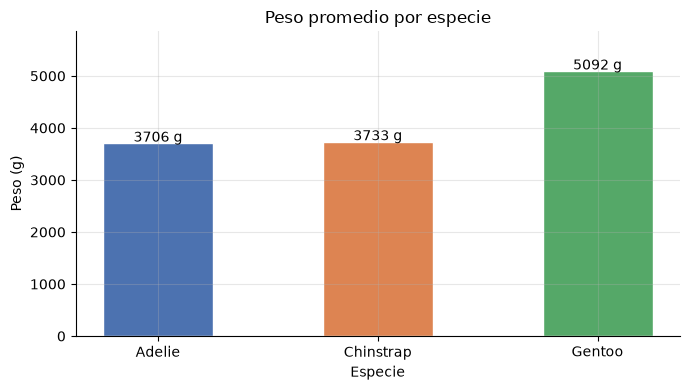

In [43]:
# Calculamos los promedios (ya los tenés de arriba como peso_por_especie)
especies = peso_por_especie.index.tolist()
pesos    = peso_por_especie.values

fig, ax = plt.subplots(figsize=(7, 4))

# Completá el gráfico de barras
# Hint: ax.bar(categorias, valores, color=[lista], edgecolor="white", width=0.5)
colores = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(especies , pesos, color=colores, edgecolor="white", width=0.5)

# Agregá las etiquetas de valor sobre cada barra
for bar, val in zip(bars, pesos):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{val:.0f} g",
        ha="center", fontsize=10
    )

ax.set_title("Peso promedio por especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Peso (g)")
ax.set_ylim(0, max(pesos) * 1.15)

plt.tight_layout()
plt.show()

### 5.3 Scatter — relación entre dos variables

Graficá largo vs. profundidad de pico, coloreando por especie.

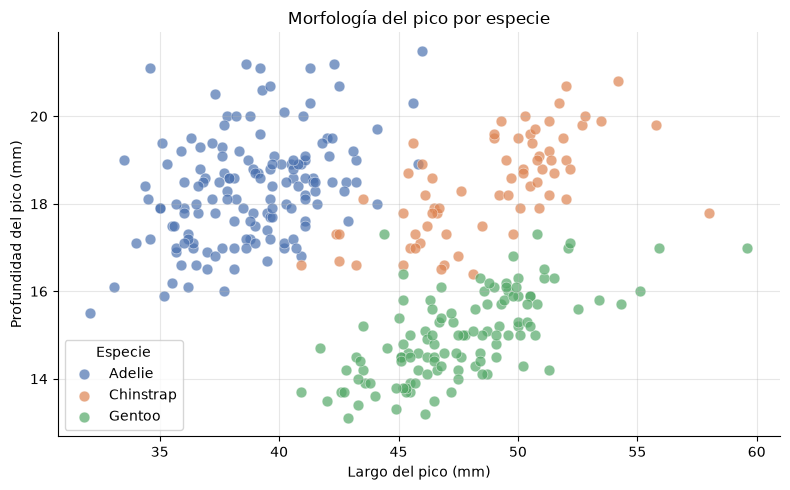

In [45]:
# Paleta de colores por especie
paleta = {"Adelie": "#4C72B0", "Chinstrap": "#DD8452", "Gentoo": "#55A868"}

fig, ax = plt.subplots(figsize=(8, 5))

# Graficá un scatter por cada especie (usá un loop)
for especie, color in paleta.items():
    # Filtrá el dataframe para que solo tenga filas de esa especie
    subset = df_limpio[df_limpio['species'] == especie]
    
    # Graficá los puntos (x = bill_length_mm, y = bill_depth_mm)
    ax.scatter(
        subset['bill_length_mm'],
        subset['bill_depth_mm'],
        color=color,
        label=especie,
        alpha=0.7,
        edgecolors="white",
        linewidth=0.4,
        s=60
    )

ax.set_xlabel("Largo del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.set_title("Morfología del pico por especie")
ax.legend(title="Especie")

plt.tight_layout()
plt.show()

### 5.4 Panel completo — tu turno

Armá un panel de 1 fila × 3 columnas con los tres gráficos anteriores juntos.

> 💡 **Hint:** `fig, axes = plt.subplots(1, 3, figsize=(W, H))`  
> Cada `axes[i]` funciona igual que `ax` en los ejemplos anteriores.

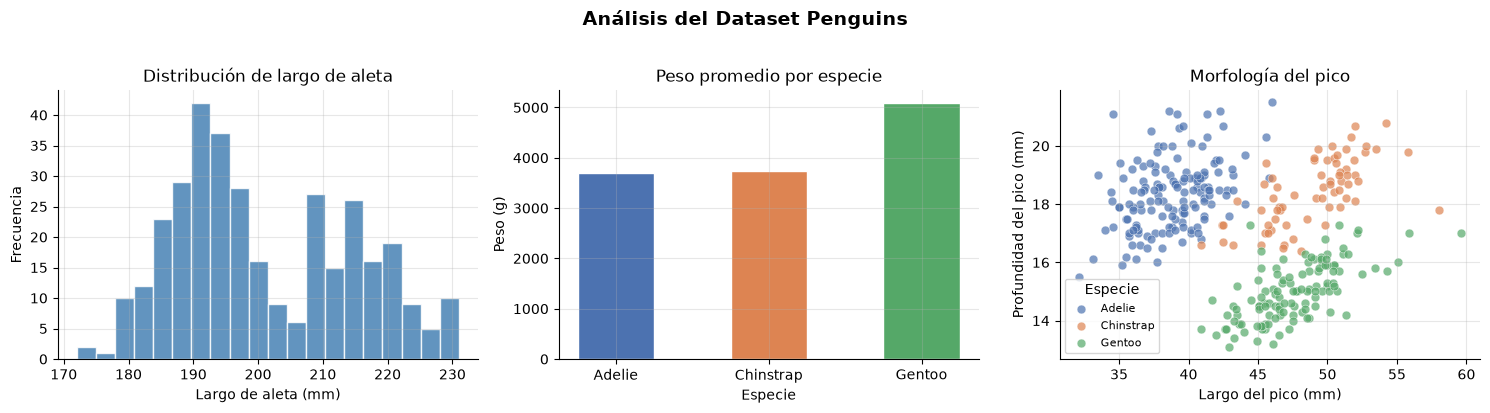

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Análisis del Dataset Penguins", fontsize=14, fontweight="bold", y=1.02)

# ── Subplot 0: histograma de flipper_length_mm ───────────
axes[0].hist(df['flipper_length_mm'], bins=20, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribución de largo de aleta")
axes[0].set_xlabel("Largo de aleta (mm)")
axes[0].set_ylabel("Frecuencia")

# ── Subplot 1: barras de peso promedio ───────────────────
axes[1].bar(especies, pesos, color=colores, edgecolor="white", width=0.5)
axes[1].set_title("Peso promedio por especie")
axes[1].set_xlabel("Especie")
axes[1].set_ylabel("Peso (g)")

# ── Subplot 2: scatter pico largo vs profundidad ─────────
for especie, color in paleta.items():
    subset = df_limpio[df_limpio["species"] == especie]
    axes[2].scatter(
        subset['bill_length_mm'], subset['bill_depth_mm'],
        color=color, label=especie, alpha=0.7,
        edgecolors="white", linewidth=0.4, s=40
    )
axes[2].set_title("Morfología del pico")
axes[2].set_xlabel("Largo del pico (mm)")
axes[2].set_ylabel("Profundidad del pico (mm)")
axes[2].legend(title="Especie", fontsize=8)

plt.tight_layout()
plt.show()

---
## Parte 6 — Preguntas de Cierre

Respondé con código y/o texto en las celdas siguientes.

**Pregunta 1:** ¿Cuál especie tiene el pico más largo en promedio?  
Usá `groupby` + `mean` para responder con código.

In [57]:
# TU CÓDIGO AQUÍ
pico_mas_largo = df_limpio.groupby('species')['bill_length_mm'].mean().max().round()
nombre_especie_pico_largo = df_limpio.groupby('species')['bill_length_mm'].mean().idxmax()
print(f'La especie con el pico mas largo es {nombre_especie_pico_largo} con un pico de {pico_mas_largo} mm')

La especie con el pico mas largo es Chinstrap con un pico de 49.0 mm


**Pregunta 2:** Filtrá solo los pingüinos de la isla `Dream` y mostrá cuántos hay de cada especie.

In [69]:
# TU CÓDIGO AQUÍ
isla_dream = df_limpio[df_limpio["island"] == "Dream"]
isla_dream["species"].value_counts()




species
Chinstrap    68
Adelie       55
Name: count, dtype: int64

**Pregunta 3 (Bonus):** Graficá un boxplot de `body_mass_g` para cada especie usando solo Matplotlib.

> 💡 **Hint:** `ax.boxplot([grupo1, grupo2, grupo3], labels=[...])`

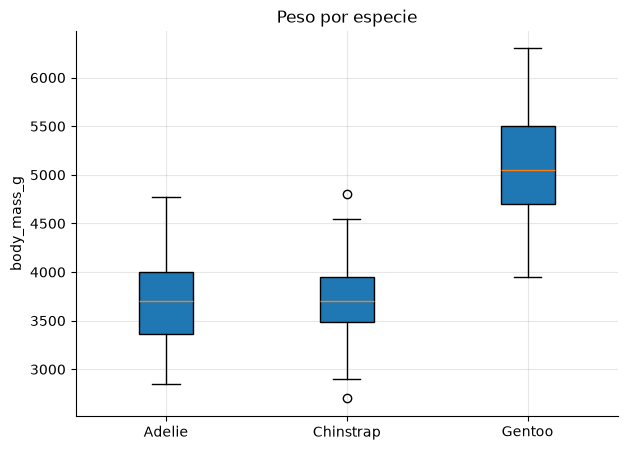

In [73]:
# TU CÓDIGO 
fig, ax = plt.subplots(figsize=(7, 5))
grupos = [df_limpio[df_limpio["species"] == s]["body_mass_g"].values
          for s in ["Adelie", "Chinstrap", "Gentoo"]]
ax.boxplot(grupos, tick_labels=["Adelie", "Chinstrap", "Gentoo"], patch_artist=True)
ax.set_title("Peso por especie")
ax.set_ylabel("body_mass_g")
plt.show()


---
## ✅ Soluciones de referencia

Ejecutá la celda de abajo solo cuando hayas terminado. Muestra una solución posible.

In [ ]:
# ── SOLUCIONES ───────────────────────────────────────────
# No hagas trampa — intentá primero 💪

soluciones = '''
=== PARTE 1 ===
df = sns.load_dataset("penguins")
df.head()

=== PARTE 2.1 ===
filas, columnas = df.shape
df.dtypes
df.describe()

=== PARTE 2.2 ===
df["species"].value_counts()
df["island"].value_counts()

=== PARTE 2.3 ===
nulos = df.isnull().sum()
(df.isnull().mean() * 100).round(1)...

=== PARTE 3.1 ===
df_limpio = df.dropna()

=== PARTE 3.2 ===
df_limpio["razon_pico"] = df_limpio["bill_length_mm"] / df_limpio["bill_depth_mm"]
df_limpio["grande"] = df_limpio["body_mass_g"] > 4500

=== PARTE 4 ===
peso_por_especie = df_limpio.groupby("species")["body_mass_g"].mean()
df_limpio.groupby(["species", "sex"])["flipper_length_mm"].median()

=== PARTE 5.1 ===
ax.hist(df_limpio["flipper_length_mm"], bins=20, ...)

=== PARTE 5.3 ===
subset = df_limpio[df_limpio["species"] == especie]
ax.scatter(subset["bill_length_mm"], subset["bill_depth_mm"], ...)

=== PARTE 5.4 ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

=== PREGUNTAS ===
# P1:
df_limpio.groupby("species")["bill_length_mm"].mean().idxmax()

# P2:
dream = df_limpio[df_limpio["island"] == "Dream"]
dream["species"].value_counts()

# P3 (Bonus):
fig, ax = plt.subplots(figsize=(7, 5))
grupos = [df_limpio[df_limpio["species"] == s]["body_mass_g"].values
          for s in ["Adelie", "Chinstrap", "Gentoo"]]
ax.boxplot(grupos, labels=["Adelie", "Chinstrap", "Gentoo"],
           patch_artist=True)
ax.set_title("Peso por especie")
ax.set_ylabel("body_mass_g")
plt.show()
'''

print(soluciones)

---
## Resumen del flujo EDA

```
1. sns.load_dataset() / pd.read_csv()  → cargar
2. .shape  .dtypes  .describe()        → entender
3. .isnull().sum()                     → detectar nulos
4. .dropna() / .fillna()               → limpiar
5. df["nueva"] = ...                   → nuevas features
6. .groupby().agg()                    → analizar por grupo
7. ax.hist / ax.bar / ax.scatter       → visualizar
```

---
*Cátedra Aprendizaje Automático — 2026*